# Real-data sub-sampling recovery (the naive algorithm)

The thesis's naive method: sub-sample the **Laplacian of the real-data similarity matrix** and see
how well the spectral partition survives.

**Protocol**
1. $S = \text{JC\_similarity(sequences)}$; reference partition $=$ STDR split
   (`partition_taxa` on the Fiedler vector of $L(S)=\operatorname{Deg}-S$).
   Keep a tree only if its reference partition is a **valid single edge** of the true tree.
2. On the valid trees, run the **standard bootstrap $p$-sweep**: sub-sample $S\to\hat S$, recompute
   the partition, and report **partition agreement, ARI, NMI** vs $p$.

Reuses the exact synthetic-experiment code: `bootstrap_p_sweep_simple` (`src/runners/p_sweep_inner.py`),
`compute_reference_partition_and_quality`, `check_partition_valid_in_tree`.

In [1]:
%load_ext autoreload
%autoreload 2

import os, sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_root = os.path.abspath(os.path.join(os.getcwd(), '..', '..', '..'))   # sub_sampled_fielder_vec
_repo = os.path.abspath(os.path.join(_root, '..'))                     # spectral-tree-inference
for p in (_root, _repo):
    if p not in sys.path:
        sys.path.insert(0, p)
for _mod in [m for m in list(sys.modules) if m.startswith(('scripts.', 'src.'))]:
    del sys.modules[_mod]

import dendropy
import spectraltree
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from matplotlib.colors import ListedColormap
from src.core.utils import compute_laplacian, compute_fiedler_from_laplacian
from src.utils.metrics import compute_reference_partition_and_quality
from src.utils.partition_validity import check_partition_valid_in_tree
from src.runners.p_sweep_inner import bootstrap_p_sweep_simple
from src.runners.real_data_bpart import fasta_to_distance
from src.utils.griffing import griffing_leading_eigvec, griffing_centered
from src.utils.bpart_sweep_cache import bpart_sweep_raw

COLOR_POS, COLOR_NEG = '#d97706', '#1d4ed8'   # orange / blue (sign partition)

# fasta: full 600-tree download (extracted); newick: 600 trees already on disk
FASTA_DIR  = Path('/Users/itayg/PythonRepo/spectral-tree-inference/data/Datasets/Fasta 1000 taxa/extracted/fasta')
NEWICK_DIR = Path(_root) / 'data' / 'real_datasets' / 'Datasets' / '1000 taxa' / 'newick'

# --- experiment parameters ---
RUN_SWEEP      = False   # screen-only pass: count valids + eta histogram. Flip True for the p-sweep.
P_VALUES       = list(np.logspace(-2, 0, 20))   # 0.01 .. 1.0, 20 log-spaced points
BOOTSTRAP_REPS = 10
NUM_GAPS       = 10
MIN_SPLIT      = 5        # STDR/test practice; min_split=1 gives a degenerate 1/999 split at n=1000
M_TAXA         = 1000
ETA_THR        = (M_TAXA / np.log(M_TAXA)) ** (1/3)   # recoverability threshold (Cor. imbalance) ~5.25
SCREEN_IDS     = [f'random_tree_{i:03d}' for i in range(1, 601)]

def load_S(tree_id):
    cm = dendropy.DnaCharacterMatrix.get(path=str(FASTA_DIR / f'{tree_id}.fasta'), schema='fasta')
    obs, meta = spectraltree.charmatrix2array(cm)
    labels = [str(t.label) for t in list(meta)]
    S = spectraltree.JC_similarity_matrix(obs)
    tree = dendropy.Tree.get(path=str(NEWICK_DIR / f'{tree_id}.nwk'), schema='newick',
                             preserve_underscores=True, taxon_namespace=cm.taxon_namespace)
    tree.encode_bipartitions()
    return S, labels, tree

def tree_leaf_index(tree, labels):
    idx = {l: i for i, l in enumerate(labels)}
    return np.array([idx[str(l.taxon.label)] for l in tree.leaf_node_iter()])

print(f'setup ok — {len(SCREEN_IDS)} ids to screen; eta threshold ~{ETA_THR:.2f}')
print('fasta:', FASTA_DIR)

setup ok — 600 ids to screen; eta threshold ~5.25
fasta: /Users/itayg/PythonRepo/spectral-tree-inference/data/Datasets/Fasta 1000 taxa/extracted/fasta


## Step 1 — STDR partition of full $S$ + validity gate

Keep only trees whose full-$S$ STDR partition is a single real edge of the true tree.

In [2]:
# Screen all SCREEN_IDS; cache the lightweight result so re-runs skip the ~18-min loop.
# We DON'T cache S (600 x 1000x1000 = too big) — the sweep cell rebuilds S per valid id when needed.
CACHE_SCREEN = Path('screen_cache_600.npz')
_screen_loaded = False
if CACHE_SCREEN.exists():
    z = np.load(CACHE_SCREEN, allow_pickle=True)
    if list(z['screen_ids']) == SCREEN_IDS:
        rows         = list(z['rows'])
        valid_ids    = list(z['valid_ids'])
        etas_valid   = z['etas_valid']
        floors_valid = z['floors_valid']
        _screen_loaded = True
        print(f'loaded screen from cache ({CACHE_SCREEN})')

if not _screen_loaded:
    rows, valid_ids, etas_valid, floors_valid = [], [], [], []
    for k, tid in enumerate(SCREEN_IDS, 1):
        if not (FASTA_DIR / f'{tid}.fasta').exists():
            continue
        S, labels, tree = load_S(tid)
        fiedler_ref = compute_fiedler_from_laplacian(compute_laplacian(S))
        partition_ref, quality, split = compute_reference_partition_and_quality(
            fiedler_ref, S, num_gaps=NUM_GAPS, min_split=MIN_SPLIT)
        eta   = split[1] / max(split[0], 1)        # clan-size imbalance of the reference partition
        floor = (min(split) == MIN_SPLIT)          # smaller clan pinned at the min_split floor?
        sidx  = tree_leaf_index(tree, labels)
        is_valid = bool(check_partition_valid_in_tree(tree, partition_ref[sidx]))
        rows.append({'tree': tid.replace('random_tree_', ''),
                     'split': f'{split[0]}/{split[1]}', 'eta': round(eta, 1),
                     'floor': floor, 'valid edge?': is_valid})
        if is_valid:
            valid_ids.append(tid); etas_valid.append(eta); floors_valid.append(floor)
        if k % 50 == 0:
            print(f'  screened {k}/{len(SCREEN_IDS)}  (valid so far: {len(valid_ids)})')
    etas_valid   = np.array(etas_valid, float)
    floors_valid = np.array(floors_valid, bool)
    np.savez(CACHE_SCREEN, screen_ids=np.array(SCREEN_IDS, dtype=object),
             rows=np.array(rows, dtype=object), valid_ids=np.array(valid_ids, dtype=object),
             etas_valid=etas_valid, floors_valid=floors_valid)
    print(f'saved screen to cache ({CACHE_SCREEN})')

etas_valid   = np.asarray(etas_valid, float)
floors_valid = np.asarray(floors_valid, bool)
n_valid = len(valid_ids)
print(f'{n_valid}/{len(rows)} trees: full-S Fiedler partition is a valid single tree edge '
      f'(num_gaps={NUM_GAPS}, min_split={MIN_SPLIT})')
pd.DataFrame(rows).set_index('tree')

loaded screen from cache (screen_cache_600.npz)
327/600 trees: full-S Fiedler partition is a valid single tree edge (num_gaps=10, min_split=5)


,split,eta,floor,valid edge?
tree,,,,
001,5/995,199.0,True,True
002,7/993,141.9,False,False
003,5/995,199.0,True,True
004,8/992,124.0,False,False
005,6/994,165.7,False,False
...,...,...,...,...
596,5/995,199.0,True,True
597,5/995,199.0,True,True
598,5/995,199.0,True,False


## Screen report — how many valid, and at what $\eta$?

Distribution of the imbalance $\eta=$ (larger clan)/(smaller clan) over the **valid** trees, with the
recoverability threshold $\eta_{\mathrm{thr}}=(m/\log m)^{1/3}$ (Cor. `eq:imbalance_failure`). Trees
left of the line are the ones uniform sub-sampling can in principle recover. `floor`-limited trees
have their smaller clan pinned at `min_split`, so their $\eta$ is a lower bound on the true cut.

valid:   327/600      invalid: 273
floor-limited (smaller clan == 5): 159/327
eta  min / 25% / median / 75% / max  =  12.3 / 141.9 / 165.7 / 199.0 / 199.0
threshold eta_thr = 5.25   ->   valid trees with eta <= thr: 0


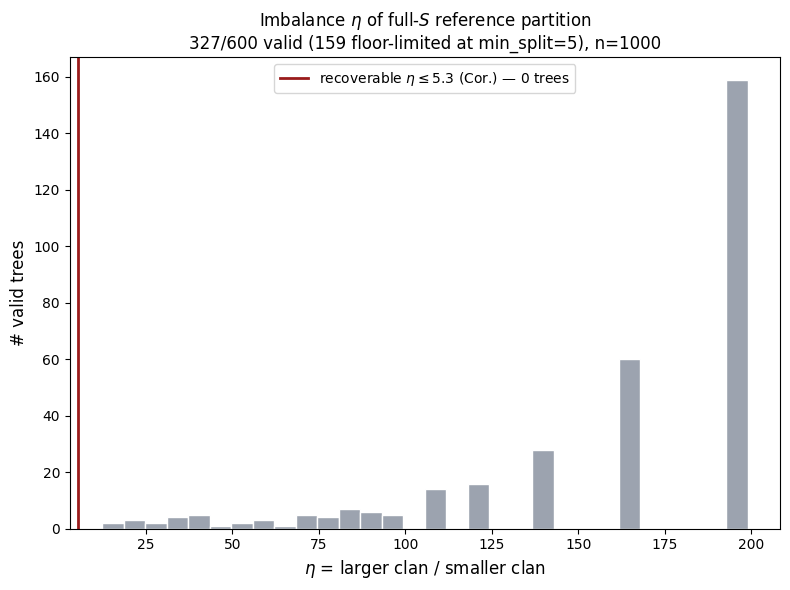

In [3]:
etas    = np.asarray(etas_valid, float)
floors  = np.asarray(floors_valid, bool)
n_floor = int(floors.sum())
n_below = int((etas <= ETA_THR).sum())

print(f'valid:   {n_valid}/{len(rows)}      invalid: {len(rows) - n_valid}')
print(f'floor-limited (smaller clan == {MIN_SPLIT}): {n_floor}/{n_valid}')
if n_valid:
    qs = np.quantile(etas, [0, .25, .5, .75, 1])
    print('eta  min / 25% / median / 75% / max  =  ' + ' / '.join(f'{q:.1f}' for q in qs))
print(f'threshold eta_thr = {ETA_THR:.2f}   ->   valid trees with eta <= thr: {n_below}')

fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(etas, bins=30, color='#9ca3af', edgecolor='white')
ax.axvline(ETA_THR, color='#991b1b', lw=2,
           label=f'recoverable $\\eta \\leq {ETA_THR:.1f}$ (Cor.) — {n_below} trees')
ax.set_xlabel(r'$\eta$ = larger clan / smaller clan', fontsize=12)
ax.set_ylabel('# valid trees', fontsize=12)
ax.set_title(f'Imbalance $\\eta$ of full-$S$ reference partition\n'
             f'{n_valid}/{len(rows)} valid ({n_floor} floor-limited at min_split={MIN_SPLIT}), n={M_TAXA}',
             fontsize=12)
ax.legend(fontsize=10); fig.tight_layout(); plt.show()

## Comparison mode — similarity (Fiedler-on-$S$) vs distance (Griffing-on-$D$)

Same validity gate, two reference operators. The Griffing screen is cached separately
(`screen_griffing_600.npz`); the cell below loads it (or recomputes if absent).

In [4]:
# --- Griffing-on-D screen (distance view) ---
fiedler_valid_ids = list(valid_ids)            # from the Fiedler screen above
CACHE_GRIFF = Path('screen_griffing_600.npz')
_g_loaded = False
if CACHE_GRIFF.exists():
    zg = np.load(CACHE_GRIFF, allow_pickle=True)
    griff_valid_ids = list(zg['valid_ids'])
    griff_etas      = np.asarray(zg['etas_valid'], float)
    _g_loaded = True
    print(f'loaded griffing screen from cache ({CACHE_GRIFF})')

if not _g_loaded:
    griff_rows, griff_valid_ids, _ge = [], [], []
    for k, tid in enumerate(SCREEN_IDS, 1):
        fpath = FASTA_DIR / f'{tid}.fasta'
        if not fpath.exists():
            continue
        D, names = fasta_to_distance(str(fpath))
        v = griffing_leading_eigvec(D)
        partition = v >= 0
        tree = dendropy.Tree.get(path=str(NEWICK_DIR / f'{tid}.nwk'), schema='newick',
                                 preserve_underscores=True)
        tree.encode_bipartitions()
        nidx = {n: i for i, n in enumerate(names)}
        sidx = np.array([nidx[str(l.taxon.label)] for l in tree.leaf_node_iter()])
        is_valid = bool(check_partition_valid_in_tree(tree, partition[sidx]))
        n1 = int(partition.sum()); n2 = len(partition) - n1
        eta = max(n1, n2) / max(min(n1, n2), 1)
        griff_rows.append((tid, eta, is_valid))
        if is_valid:
            griff_valid_ids.append(tid); _ge.append(eta)
        if k % 50 == 0:
            print(f'  griffing screened {k}/{len(SCREEN_IDS)} (valid: {len(griff_valid_ids)})')
    griff_etas = np.array(_ge, float)
    np.savez(CACHE_GRIFF, valid_ids=np.array(griff_valid_ids, dtype=object),
             etas_valid=griff_etas, rows=np.array(griff_rows, dtype=object))
    print(f'saved griffing screen to cache ({CACHE_GRIFF})')

print(f'griffing-on-D: {len(griff_valid_ids)} valid   '
      f'eta min/median/max = {griff_etas.min():.1f}/{np.median(griff_etas):.1f}/{griff_etas.max():.1f}')

loaded griffing screen from cache (screen_griffing_600.npz)
griffing-on-D: 215 valid   eta min/median/max = 1.0/1.5/4.2


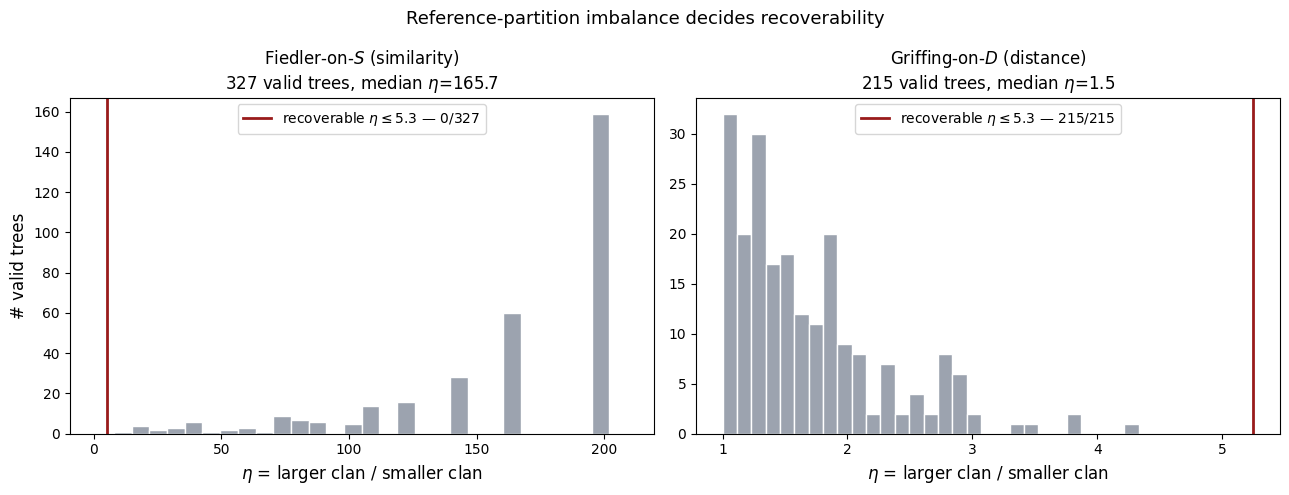

In [5]:
# side-by-side eta histograms — each on its OWN x-range (shared scale hides the griffing shape)
fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 5))

for ax, data, name in [(axL, etas_valid, 'Fiedler-on-$S$ (similarity)'),
                       (axR, griff_etas, 'Griffing-on-$D$ (distance)')]:
    nbelow = int((data <= ETA_THR).sum())
    ax.hist(data, bins=30, range=(1, data.max() * 1.05), color='#9ca3af', edgecolor='white')
    ax.axvline(ETA_THR, color='#991b1b', lw=2,
               label=f'recoverable $\\eta\\leq{ETA_THR:.1f}$ — {nbelow}/{len(data)}')
    ax.set_xlabel(r'$\eta$ = larger clan / smaller clan', fontsize=12)
    ax.set_title(f'{name}\n{len(data)} valid trees, median $\\eta$={np.median(data):.1f}', fontsize=12)
    ax.legend(fontsize=10)
axL.set_ylabel('# valid trees', fontsize=12)
fig.suptitle('Reference-partition imbalance decides recoverability', fontsize=13)
fig.tight_layout(); plt.show()

### One tree, three partitions

Patristic tree + a solid 2-color sign strip per operator (one demo tree valid in **both** methods,
nearest the Griffing median $\eta$). Fiedler-on-$S$ snips a tiny fringe; Griffing-on-$D$ cuts the deep
balanced divide; Fiedler-of-$L(D)$ shown for contrast.

demo tree random_tree_557  (valid in both; griffing eta=1.49);  114 trees valid in both


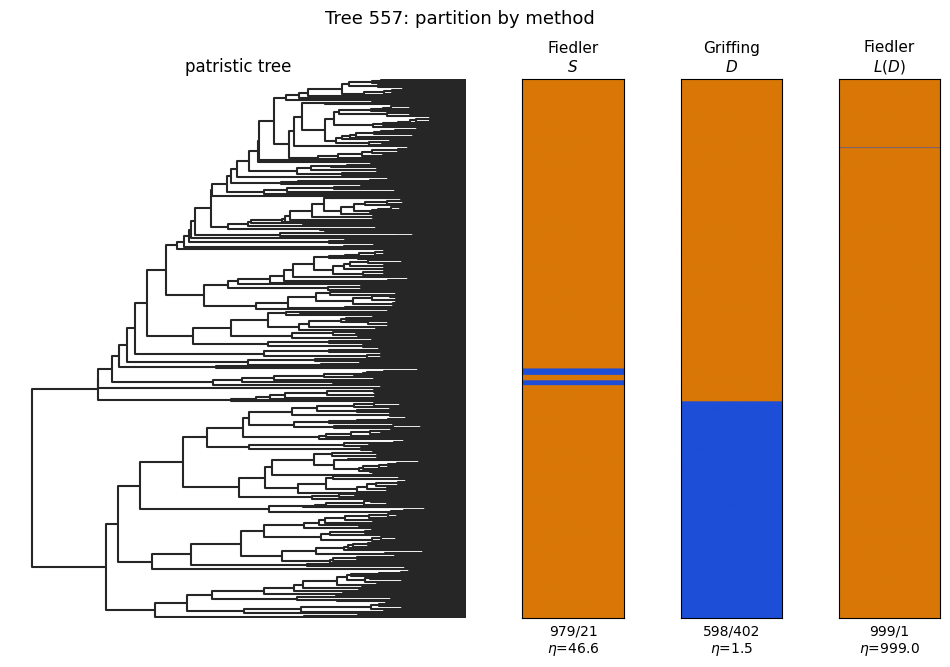

In [6]:
def patristic_distance_matrix(tree):
    leaf_taxa = [leaf.taxon for leaf in tree.leaf_node_iter()]
    n = len(leaf_taxa)
    pdm = tree.phylogenetic_distance_matrix()
    Dp = np.zeros((n, n))
    for i in range(n):
        for j in range(i + 1, n):
            d = pdm.distance(leaf_taxa[i], leaf_taxa[j])
            Dp[i, j] = Dp[j, i] = d
    return Dp

def sign_orient(v):
    s = (np.asarray(v) >= 0).astype(int)
    if s.sum() < len(s) - s.sum():   # make the majority side = 1 (orange) for consistent coloring
        s = 1 - s
    return s

# pick one tree valid in BOTH methods, nearest the griffing-median eta
_fset = set(fiedler_valid_ids)
both  = [t for t in griff_valid_ids if t in _fset]
_gmap = {t: e for t, e in zip(griff_valid_ids, griff_etas)}
_med  = np.median([_gmap[t] for t in both])
tid   = min(both, key=lambda t: abs(_gmap[t] - _med))
print(f'demo tree {tid}  (valid in both; griffing eta={_gmap[tid]:.2f});  {len(both)} trees valid in both')

S, labels, tree = load_S(tid)
D, names = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
vS  = compute_fiedler_from_laplacian(compute_laplacian(S))     # labels order
vGD = griffing_leading_eigvec(D)                               # names order
vFD = compute_fiedler_from_laplacian(compute_laplacian(D))     # names order

s_to_tree = tree_leaf_index(tree, labels)
nidx = {n: i for i, n in enumerate(names)}
d_to_tree = np.array([nidx[str(l.taxon.label)] for l in tree.leaf_node_iter()])
strips = [('Fiedler\n$S$',    sign_orient(vS[s_to_tree])),
          ('Griffing\n$D$',   sign_orient(vGD[d_to_tree])),
          ('Fiedler\n$L(D)$', sign_orient(vFD[d_to_tree]))]

Dpat = patristic_distance_matrix(tree)
Z = hierarchy.linkage(squareform(Dpat, checks=False), method='average')

fig = plt.figure(figsize=(12, 7))
gs = fig.add_gridspec(1, 4, width_ratios=[4.5, 1, 1, 1], wspace=0.30)
ax_tree = fig.add_subplot(gs[0, 0])
dendro = hierarchy.dendrogram(Z, ax=ax_tree, orientation='left', no_labels=True,
                              color_threshold=0, above_threshold_color='#262626')
leaf_order = dendro['leaves']
ax_tree.set_title('patristic tree', fontsize=12)
ax_tree.set_xticks([]); ax_tree.set_yticks([])
for sp in ax_tree.spines.values(): sp.set_visible(False)

cmap = ListedColormap([COLOR_NEG, COLOR_POS])
for j, (name, sgn) in enumerate(strips, start=1):
    ax = fig.add_subplot(gs[0, j])
    ax.imshow(sgn[leaf_order][:, None], aspect='auto', cmap=cmap, vmin=0, vmax=1, origin='lower')
    n1 = int(sgn.sum()); n2 = len(sgn) - n1
    eta = max(n1, n2) / max(min(n1, n2), 1)
    ax.set_title(name, fontsize=11)
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_xlabel(f'{max(n1,n2)}/{min(n1,n2)}\n$\\eta$={eta:.1f}', fontsize=10)
fig.suptitle(f"Tree {tid.replace('random_tree_','')}: partition by method", fontsize=13)
plt.show()

### What each operator sees — raw inputs vs operators

Same demo tree, rows/cols sorted by the Griffing axis. **Row 1 — raw inputs $S,D$ (shared scale).**
**Row 2 — operators $L=\mathrm{Deg}(S)-S$ (Fiedler) and $B$ = centered $D$ (Griffing), shared diverging
scale** driven by $B$'s off-diagonal spread so its blocks are visible ($L$'s larger entries saturate).
$L$ is structureless → degenerate cut; $B$ shows two balanced $\pm$ blocks → stable bimodal split.
Diverging panels use a yellow-centered map so $0$ is visible.

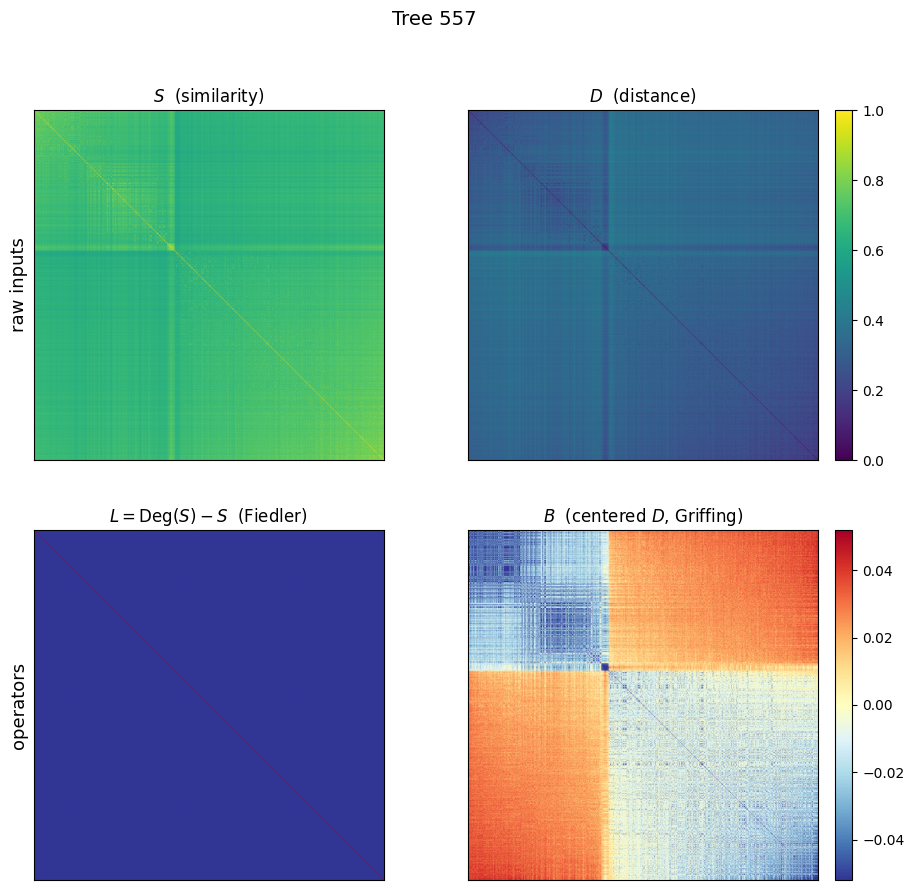

In [7]:
S_m, labels_m, _t_m = load_S(tid)              # tid = the demo tree from the anatomy cell
D_m, names_m = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
L_m = compute_laplacian(S_m)
B_m = griffing_centered(D_m)
order = np.argsort(griffing_leading_eigvec(D_m))   # sort taxa along the Griffing axis
_ro = lambda M: M[order][:, order]
Sr, Dr, Lr, Br = _ro(S_m), _ro(D_m), _ro(L_m), _ro(B_m)

# row 1: S & D share one sequential scale; row 2: L & B share one diverging scale,
# driven by B's (smaller) off-diagonal spread so B's blocks are visible; L's larger entries saturate.
v1min = min(Sr.min(), Dr.min()); v1max = max(Sr.max(), Dr.max())
_off = ~np.eye(Lr.shape[0], dtype=bool)
v2 = float(np.percentile(np.abs(Br[_off]), 95))

DIV = 'RdYlBu_r'                                 # diverging map with a visible (yellow) center, not white
fig, axes = plt.subplots(2, 2, figsize=(11, 10))
im_top = axes[0, 0].imshow(Sr, cmap='viridis', vmin=v1min, vmax=v1max); axes[0, 0].set_title('$S$  (similarity)', fontsize=12)
axes[0, 1].imshow(Dr, cmap='viridis', vmin=v1min, vmax=v1max);          axes[0, 1].set_title('$D$  (distance)', fontsize=12)
im_bot = axes[1, 0].imshow(Lr, cmap=DIV, vmin=-v2, vmax=v2);             axes[1, 0].set_title('$L=\\mathrm{Deg}(S)-S$  (Fiedler)', fontsize=12)
axes[1, 1].imshow(Br, cmap=DIV, vmin=-v2, vmax=v2);                     axes[1, 1].set_title('$B$  (centered $D$, Griffing)', fontsize=12)

for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
axes[0, 0].set_ylabel('raw inputs', fontsize=13)
axes[1, 0].set_ylabel('operators', fontsize=13)
fig.colorbar(im_top, ax=[axes[0, 0], axes[0, 1]], fraction=0.046, pad=0.02)
fig.colorbar(im_bot, ax=[axes[1, 0], axes[1, 1]], fraction=0.046, pad=0.02)
fig.suptitle(f"Tree {tid.replace('random_tree_','')}", fontsize=14)
plt.show()

### Recovery curve — similarity vs distance

Median NMI vs $p$ over the trees valid in **both** methods (up to 100), each method recovering its own
full-matrix reference. Cache built by `compare_sweep.py`.

computing comparison sweep: 100 trees x 20 p x 10 reps (slow)...


  swept 5/100


  swept 10/100


  swept 15/100


  swept 20/100


...

  swept 80/100


  swept 85/100


  swept 90/100


  swept 95/100


  swept 100/100
saved comparison sweep cache (compare_sweep_100.npz)


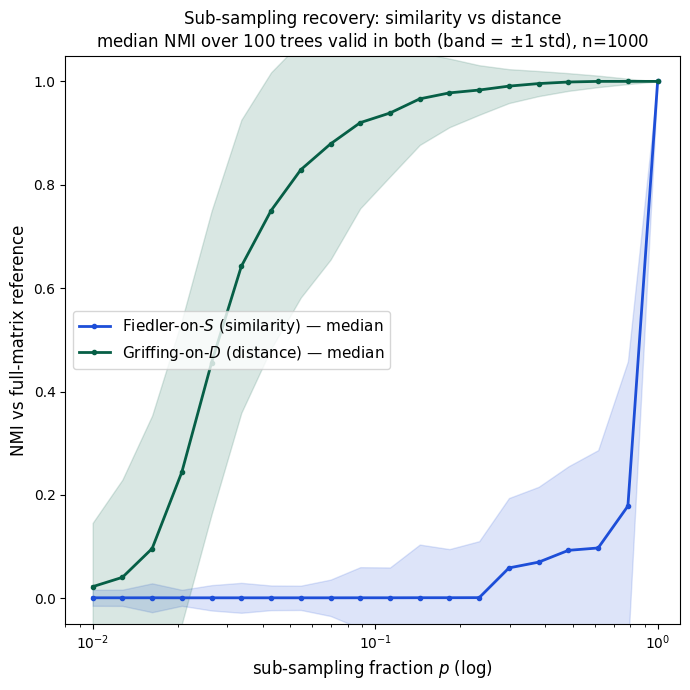

In [8]:
# self-computing, p-aware cache: recomputes whenever P_VALUES or the cohort changes
N_COMPARE, REPS = 100, 10
CMP = Path('compare_sweep_100.npz')
_pvc = np.round(P_VALUES, 6)
cohort = sorted([t for t in griff_valid_ids if t in set(fiedler_valid_ids)])[:N_COMPARE]

_cmp_loaded = False
if CMP.exists():
    zc = np.load(CMP, allow_pickle=True)
    if list(np.round(zc['p_values'], 6)) == list(_pvc) and list(zc['tree_ids']) == cohort:
        nmi_S, nmi_G = zc['nmi_S'], zc['nmi_G']; _cmp_loaded = True
        print(f'loaded comparison sweep from cache ({CMP})')
    else:
        print('cache present but p_values / cohort changed — recomputing')

if not _cmp_loaded:
    print(f'computing comparison sweep: {len(cohort)} trees x {len(P_VALUES)} p x {REPS} reps (slow)...')
    nmi_S, nmi_G = [], []
    for ti, tid in enumerate(cohort):
        S, labels, tree = load_S(tid)
        fr = compute_fiedler_from_laplacian(compute_laplacian(S))
        pr, _, _ = compute_reference_partition_and_quality(fr, S, num_gaps=NUM_GAPS, min_split=MIN_SPLIT)
        out = bootstrap_p_sweep_simple(S, fr, P_VALUES, bootstrap_reps=REPS, seed=1000 * ti,
                                       num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                                       partition_ref=pr, partition_method='sigma2')
        nmi_S.append(np.asarray(out['partition_nmi_M'], float))
        D, names = fasta_to_distance(str(FASTA_DIR / f'{tid}.fasta'))
        raw = bpart_sweep_raw(D, P_VALUES, reps=REPS, seed_base=1000 * ti)
        nmi_G.append(np.array([float(np.mean(pp['nmi'])) for pp in raw['per_p']]))
        if (ti + 1) % 5 == 0:
            print(f'  swept {ti+1}/{len(cohort)}')
    nmi_S = np.vstack(nmi_S); nmi_G = np.vstack(nmi_G)
    np.savez(CMP, p_values=_pvc, tree_ids=np.array(cohort, dtype=object), nmi_S=nmi_S, nmi_G=nmi_G)
    print(f'saved comparison sweep cache ({CMP})')

P = np.asarray(_pvc, float)
nt = nmi_S.shape[0]
fig, ax = plt.subplots(figsize=(7, 7))
for data, name, col in [(nmi_S, 'Fiedler-on-$S$ (similarity)', '#1d4ed8'),
                        (nmi_G, 'Griffing-on-$D$ (distance)',   '#065f46')]:
    med = np.nanmedian(data, 0); sd = np.nanstd(data, 0)
    ax.plot(P, med, color=col, lw=2, marker='o', ms=3, label=f'{name} — median')
    ax.fill_between(P, med - sd, med + sd, color=col, alpha=0.15)
ax.set_xscale('log')
ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
ax.set_ylabel('NMI vs full-matrix reference', fontsize=12)
ax.set_title(f'Sub-sampling recovery: similarity vs distance\n'
             f'median NMI over {nt} trees valid in both (band = $\\pm$1 std), n=1000', fontsize=12)
ax.set_xlim(P.min() * 0.8, 1.2); ax.set_ylim(-0.05, 1.05)
ax.legend(fontsize=11, loc='center left')
fig.tight_layout(); plt.show()

## Step 2 — standard bootstrap $p$-sweep on the valid trees

`bootstrap_p_sweep_simple` is the same helper the synthetic experiments use: per $p$ it sub-samples
$S$ (`bootstrap_reps` times), recomputes & sign-aligns the Fiedler vector, averages, partitions with
`partition_taxa`, and returns partition agreement / ARI / NMI against the reference.

In [9]:
if not RUN_SWEEP:
    print('RUN_SWEEP=False — screen-only pass; skipping the p-sweep.')
else:
    CACHE = Path('recovery_arrays.npz')   # lets plot-only tweaks skip the sweep
    _pv = np.round(P_VALUES, 6)
    _loaded = False
    if CACHE.exists():
        z = np.load(CACHE, allow_pickle=True)
        if list(z['p_values']) == list(_pv) and list(z['valid_ids']) == list(valid_ids):
            agr, ari, nmi = z['agr'], z['ari'], z['nmi']
            _loaded = True
            print(f'loaded sweep arrays from cache ({CACHE})')

    if not _loaded:
        agr, ari, nmi = [], [], []   # one row per valid tree, columns = p
        for ti, tid in enumerate(valid_ids):
            S, labels, tree = load_S(tid)                       # rebuild S (not cached)
            fiedler_ref = compute_fiedler_from_laplacian(compute_laplacian(S))
            partition_ref, _, _ = compute_reference_partition_and_quality(
                fiedler_ref, S, num_gaps=NUM_GAPS, min_split=MIN_SPLIT)
            out = bootstrap_p_sweep_simple(
                S, fiedler_ref, P_VALUES,
                bootstrap_reps=BOOTSTRAP_REPS, seed=1000 * ti,
                num_gaps=NUM_GAPS, min_split=MIN_SPLIT,
                partition_ref=partition_ref, partition_method='sigma2')
            agr.append(out['partition_agreement_M'])
            ari.append(out['partition_ari_M'])
            nmi.append(out['partition_nmi_M'])
            print(f"  swept {tid} ({ti + 1}/{n_valid})")
        agr, ari, nmi = np.array(agr), np.array(ari), np.array(nmi)
        np.savez(CACHE, p_values=_pv, valid_ids=np.array(valid_ids, dtype=object),
                 agr=agr, ari=ari, nmi=nmi, etas_valid=etas_valid)
        print(f'saved sweep arrays to cache ({CACHE})')
    summary = pd.DataFrame({
        'p': np.round(P_VALUES, 5),
        'agreement % (median)': np.nanmedian(agr, axis=0).round(1),
        'ARI (median)':         np.nanmedian(ari, axis=0).round(3),
        'NMI (median)':         np.nanmedian(nmi, axis=0).round(3),
    }).set_index('p')
    print(summary)

RUN_SWEEP=False — screen-only pass; skipping the p-sweep.


In [10]:
if RUN_SWEEP:
    P = np.array(P_VALUES)
    med = np.nanmedian(nmi, axis=0)
    sd  = np.nanstd(nmi, axis=0)

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.plot(P, med, color='#065f46', lw=2, marker='o', ms=3, label='NMI (median)')
    ax.fill_between(P, med - sd, med + sd, color='#065f46', alpha=0.15)
    ax.set_xscale('log')
    ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
    ax.set_ylabel('NMI', fontsize=12)
    ax.set_title(f'Real-data sub-sampling recovery — STDR partition\n'
                 f'median NMI over {n_valid} valid trees (band = $\\pm$1 std), n=1000', fontsize=13)
    ax.set_xlim(P.min() * 0.8, 1.2); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=11, loc='upper left')
    fig.tight_layout(); plt.show()

## Per-tree recovery at $\eta$ quantiles (sweep only)

NMI recovery vs $p$ for the trees nearest the min / 25% / median / max $\eta$ quantiles.

In [11]:
if RUN_SWEEP:
    qsel = {'min':    etas_valid.min(),
            '25%':    np.quantile(etas_valid, 0.25),
            'median': np.quantile(etas_valid, 0.50),
            'max':    etas_valid.max()}
    qcol = {'min': '#1d4ed8', '25%': '#0d9488', 'median': '#b45309', 'max': '#991b1b'}
    sel = {q: int(np.argmin(np.abs(etas_valid - t))) for q, t in qsel.items()}

    P = np.array(P_VALUES)
    fig, ax = plt.subplots(figsize=(7, 7))
    for q, idx in sel.items():
        tid = valid_ids[idx].replace('random_tree_', '')
        ax.plot(P, nmi[idx], color=qcol[q], lw=2, marker='o', ms=3,
                label=f'{q}: $\\eta$={etas_valid[idx]:.0f} (tree {tid})')
    ax.set_xscale('log')
    ax.set_xlabel('sub-sampling fraction $p$ (log)', fontsize=12)
    ax.set_ylabel('NMI', fontsize=12)
    ax.set_title('Per-tree NMI recovery at $\\eta$ quantiles', fontsize=12)
    ax.set_xlim(P.min() * 0.95, 1.05); ax.set_ylim(-0.05, 1.05); ax.legend(fontsize=9, loc='upper left')
    fig.tight_layout(); plt.show()